In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [8]:
# Load data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset Shape:", df.shape)  # (7043, 21) [attached_file:1]
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())

Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

In [14]:
#Basic Exploration
print("Churn value counts:")
print(df['Churn'].value_counts())
print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetServi

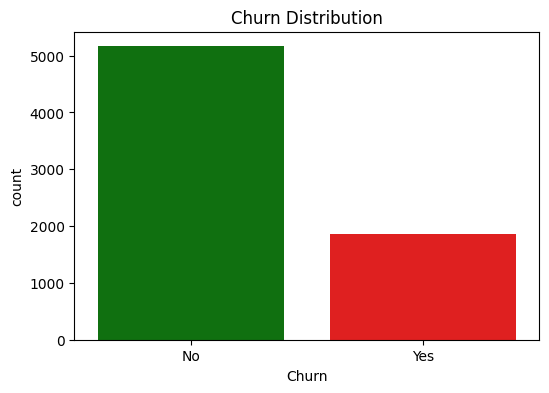

In [18]:
#Plot 1: Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['green','red'])
plt.title('Churn Distribution')
plt.show()

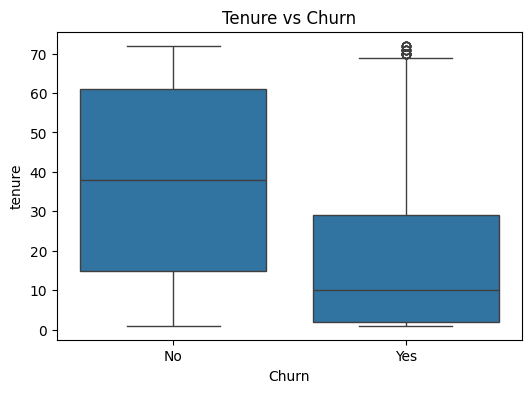

In [19]:
#Plot 2: Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

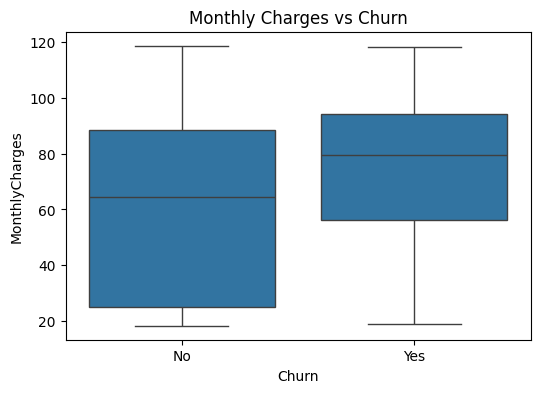

In [20]:
#Plot 3: MonthlyCharges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

In [17]:
# Clean: Convert TotalCharges to numeric, drop customerID

print("TotalCharges dtype before:", df['TotalCharges'].dtype)
print("Sample TotalCharges values before:", df['TotalCharges'].head().tolist())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype after:", df['TotalCharges'].dtype)
print("TotalCharges NaN count after conversion:", df['TotalCharges'].isnull().sum())

rows_before = df.shape[0]
df = df.dropna()
rows_after = df.shape[0]
print(f"Rows before dropna: {rows_before}, after dropna: {rows_after}, dropped: {rows_before - rows_after}")
if 'customerID' in df.columns:
  print("Dropping column: customerID")
  df = df.drop('customerID', axis=1)
  print("Shape after cleaning:", df.shape)
  print("Columns after cleaning:", df.columns.tolist())

TotalCharges dtype before: float64
Sample TotalCharges values before: [29.85, 1889.5, 108.15, 1840.75, 151.65]
TotalCharges dtype after: float64
TotalCharges NaN count after conversion: 0
Rows before dropna: 7032, after dropna: 7032, dropped: 0
Dropping column: customerID
Shape after cleaning: (7032, 20)
Columns after cleaning: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [27]:
# Encode target
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Churn numeric value counts:")
print(df['Churn'].value_counts())

Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Churn numeric value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [22]:
# Encode categoricals
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", cat_cols.tolist())
for col in cat_cols:
  print(f"Encoding column: {col}")
  df = pd.get_dummies(df, columns=[col], drop_first=True)
  print("Shape after encoding:", df.shape)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoding column: gender
Shape after encoding: (7032, 20)
Encoding column: Partner
Shape after encoding: (7032, 20)
Encoding column: Dependents
Shape after encoding: (7032, 20)
Encoding column: PhoneService
Shape after encoding: (7032, 20)
Encoding column: MultipleLines
Shape after encoding: (7032, 21)
Encoding column: InternetService
Shape after encoding: (7032, 22)
Encoding column: OnlineSecurity
Shape after encoding: (7032, 23)
Encoding column: OnlineBackup
Shape after encoding: (7032, 24)
Encoding column: DeviceProtection
Shape after encoding: (7032, 25)
Encoding column: TechSupport
Shape after encoding: (7032, 26)
Encoding column: StreamingTV
Shape after encoding: (7032, 27)
Encoding column: StreamingMovies
Shape af

In [23]:
# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (7032, 30)
Target vector shape: (7032,)


In [24]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train value counts:")
print(y_train.value_counts())
print("y_test value counts:")
print(y_test.value_counts())

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train value counts:
Churn
0    4130
1    1495
Name: count, dtype: int64
y_test value counts:
Churn
0    1033
1     374
Name: count, dtype: int64


In [28]:
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)


In [31]:
# SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print("X_train_sm shape:", X_train_sm.shape)

Class distribution before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64
Class distribution after SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64
X_train_sm shape: (8260, 30)


In [30]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
print("Parameter grid:", param_grid)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc')
print("Fitting GridSearchCV...")
grid.fit(X_train_sm, y_train_sm)
print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Parameter grid: {'n_estimators': [100, 200], 'max_depth': [10, 20]}
Fitting GridSearchCV...
Best parameters: {'max_depth': 20, 'n_estimators': 200}
Best CV ROC-AUC: 0.9309536023544723


Classification report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.63      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.79      1407

ROC-AUC: 0.8195976621749641
Confusion matrix:
[[866 167]
 [138 236]]


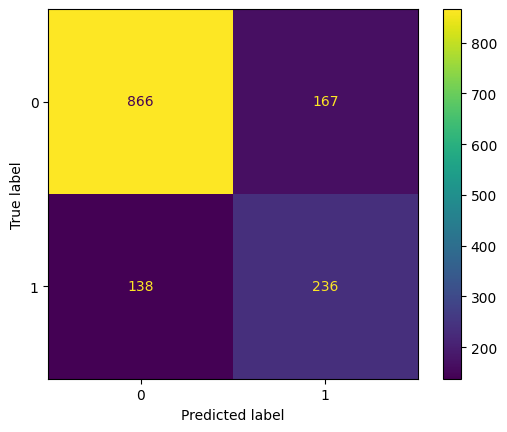

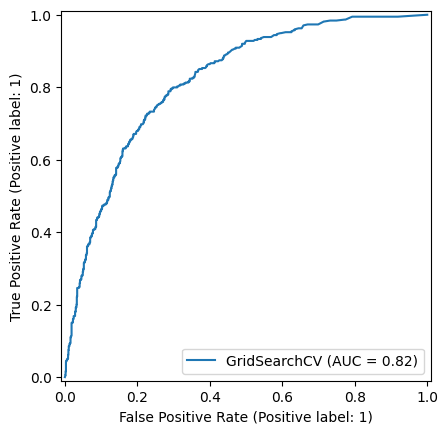

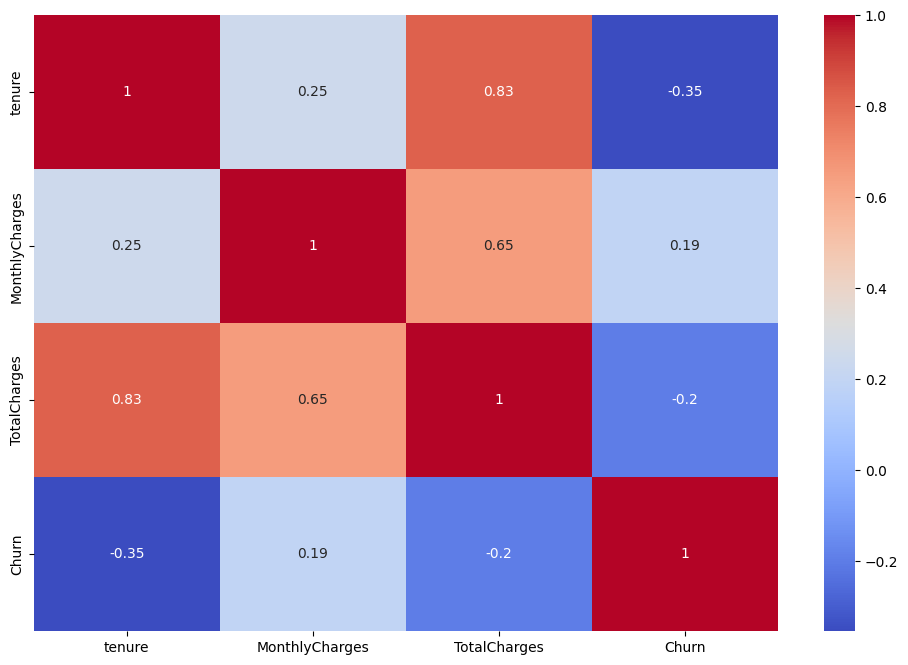

In [32]:
# Predict
y_pred = grid.predict(X_test)
y_pred_proba = grid.predict_proba(X_test)[:, 1]
print("Classification report:")
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", roc)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# ROC Curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(grid, X_test, y_test)
plt.show()

# Correlation Heatmap (pre-encoding)
plt.figure(figsize=(12,8))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [33]:
# Results
print("Best Params:", grid.best_params_)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

Best Params: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.63      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.79      1407

ROC-AUC: 0.8195976621749641


In [34]:
# Feature importance (adapt columns as needed)
importances = pd.Series(grid.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 importance features:")
print(importances.head(10))

Top 10 importance features:
tenure                            0.153803
TotalCharges                      0.138487
MonthlyCharges                    0.120690
Contract_Two year                 0.066480
PaymentMethod_Electronic check    0.046465
OnlineSecurity_Yes                0.044477
InternetService_Fiber optic       0.043286
Contract_One year                 0.037787
TechSupport_Yes                   0.031310
PaperlessBilling_Yes              0.029520
dtype: float64


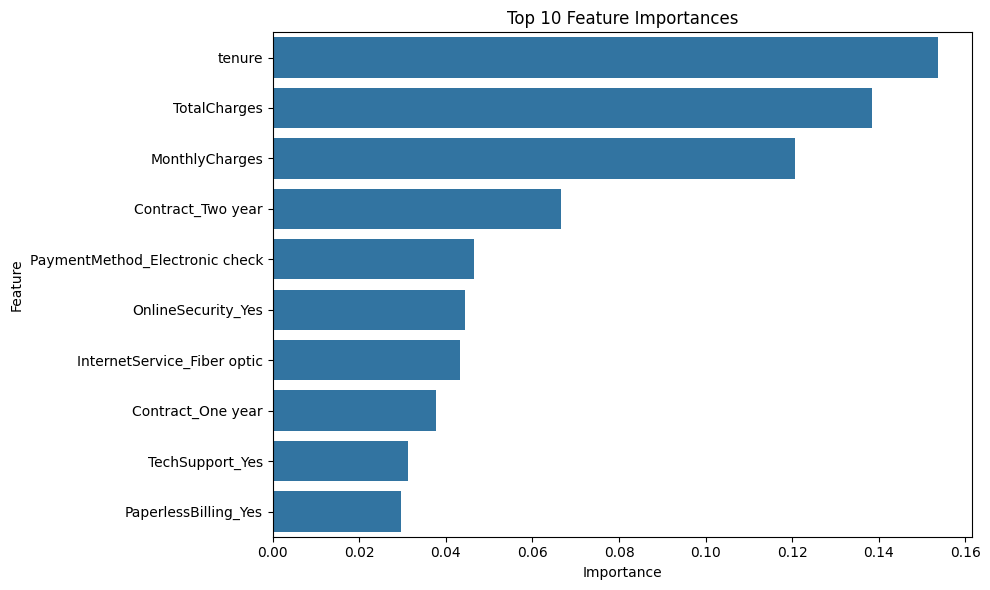

In [37]:
#Plot 6: Feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()